In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from anndata import concat as ad_concat

# ---------- Function to Load and Annotate One Sample ----------
def load_and_annotate_sample(sample_name, sample_path, region_path, condition):
    print(f"\n📦 Loading sample: {sample_name}")

    # Step 1: Load Visium spatial expression data
    adata = sc.read_visium(
        path=sample_path,
        count_file="filtered_feature_bc_matrix.h5"
    )
    adata.var_names_make_unique()
    print(f"✅ Loaded {adata.n_obs} spots and {adata.n_vars} genes.")

    # Step 2: Load subregion annotation
    region_df = pd.read_csv(region_path, sep="\t")
    region_df["Hippocampal subregions"] = region_df["Hippocampal subregions"].replace("nan", np.nan)
    region_df = region_df.dropna(subset=["Hippocampal subregions"])
    region_df["Cell name"] = region_df["Cell name"].astype(str).str.strip().str.replace("-1", "", regex=False)
    region_df.rename(columns={"Cell name": "barcode"}, inplace=True)
    region_df = region_df[["barcode", "Hippocampal subregions"]]
    print(f"✅ Region labels: {region_df['Hippocampal subregions'].value_counts().to_dict()}")

    # Step 3: Merge into AnnData.obs
    adata.obs["barcode"] = adata.obs_names.str.replace("-1", "", regex=False)
    adata.obs = adata.obs.merge(region_df, on="barcode", how="left")
    adata.obs["Hippocampal subregions"] = adata.obs["Hippocampal subregions"].astype("category")
    print(f"✅ Subregion merge result:\n{adata.obs['Hippocampal subregions'].value_counts(dropna=False)}")

    # Step 4: Add sample and condition metadata
    adata.obs["sample_id"] = sample_name
    adata.obs["condition"] = condition

    # Save raw counts (important for cell2location!)
    adata.raw = adata.copy()

    return adata

In [2]:
# ---------- Load All Samples ----------
base_data_folder = "/Users/bhavanasanghi/Downloads"
region_annotation_folder = f"{base_data_folder}/Partek_YannVRB_VisiumSpatialGeneExpression_HC_SOR_01_2F12_2F2022_exported"

sample_metadata = [
    ("Sample1SOR", "SOR"),
    ("Sample2SOR", "SOR"),
    ("Sample3SOR", "SOR"),
    ("Sample4SOR", "SOR"),
    ("Sample5HC", "HC"),
    ("Sample6HC", "HC"),
    ("Sample7HC", "HC"),
    ("Sample8HC", "HC"),
    ("Sample9HC", "HC"),
    ("Sample10SOR", "SOR"),
    ("Sample13HC", "HC"),
    ("Sample14SOR", "SOR"),
    ("Sample15HC", "HC"),
    ("Sample16SOR", "SOR"),
]

all_adata_list = []

for i, (sample_name, condition) in enumerate(sample_metadata, start=1):
    sample_path = f"{base_data_folder}/spatial{i}"
    region_path = f"{region_annotation_folder}/{sample_name}.txt"
    adata = load_and_annotate_sample(sample_name, sample_path, region_path, condition)
    all_adata_list.append(adata)

# ---------- Ensure Shared Genes ----------
shared_genes = set(all_adata_list[0].var_names)
for ad in all_adata_list[1:]:
    shared_genes &= set(ad.var_names)
shared_genes = list(shared_genes)

# Subset to shared genes
for i in range(len(all_adata_list)):
    all_adata_list[i] = all_adata_list[i][:, shared_genes].copy()

# ---------- Concatenate All Data ----------
adata_combined = ad_concat(all_adata_list, join="outer", merge="same")

# ---------- Filter CA2+CA3 Spots ----------
adata_ca3_all = adata_combined[adata_combined.obs["Hippocampal subregions"] == "CA2+CA3"].copy()

# ---------- Summary Stats ----------
print(f"\n🧠 Total CA2+CA3 spots across all samples: {adata_ca3_all.n_obs}")
print("📊 Spots per sample:")
print(adata_ca3_all.obs["sample_id"].value_counts())
print("📊 Conditions represented:")
print(adata_ca3_all.obs["condition"].value_counts())


📦 Loading sample: Sample1SOR


/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✅ Loaded 2547 spots and 32285 genes.
✅ Region labels: {'Stratum radiatum': 18, 'DG': 16, 'Stratum oriens': 14, 'CA2+CA3': 14, 'CA1': 9}
✅ Subregion merge result:
Hippocampal subregions
NaN                 2476
Stratum radiatum      18
DG                    16
CA2+CA3               14
Stratum oriens        14
CA1                    9
Name: count, dtype: int64

📦 Loading sample: Sample2SOR


/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✅ Loaded 2906 spots and 32285 genes.
✅ Region labels: {'Stratum radiatum': 27, 'Stratum oriens': 19, 'CA1': 16, 'DG': 14, 'CA2+CA3': 14}
✅ Subregion merge result:
Hippocampal subregions
NaN                 2816
Stratum radiatum      27
Stratum oriens        19
CA1                   16
CA2+CA3               14
DG                    14
Name: count, dtype: int64

📦 Loading sample: Sample3SOR


...

/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


✅ Loaded 2778 spots and 32285 genes.
✅ Region labels: {'Stratum radiatum': 34, 'DG': 27, 'CA1': 23, 'CA2+CA3': 16, 'Stratum oriens': 15}
✅ Subregion merge result:
Hippocampal subregions
NaN                 2663
Stratum radiatum      34
DG                    27
CA1                   23
CA2+CA3               16
Stratum oriens        15
Name: count, dtype: int64


/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/aligned_d


🧠 Total CA2+CA3 spots across all samples: 189
📊 Spots per sample:
sample_id
Sample14SOR    17
Sample13HC     16
Sample15HC     16
Sample16SOR    16
Sample4SOR     15
Sample10SOR    15
Sample1SOR     14
Sample2SOR     14
Sample8HC      14
Sample6HC      12
Sample7HC      12
Sample5HC      10
Sample9HC      10
Sample3SOR      8
Name: count, dtype: int64
📊 Conditions represented:
condition
SOR    99
HC     90
Name: count, dtype: int64


/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


✅ Raw matrix shape (cells x genes): (92384, 54232)
✅ Metadata columns: ['bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'tscp_count_50dup', 'read_count', 'bc1_well', 'bc2_well', 'bc3_well', 'bc1_wind', 'bc2_wind', 'bc3_wind']
✅ Normalization and log1p complete for plotting.
✅ Genes found in Visium CA3 data: ['Fos', 'Arc', 'Nr4a2', 'Egr1', 'Sgk1']


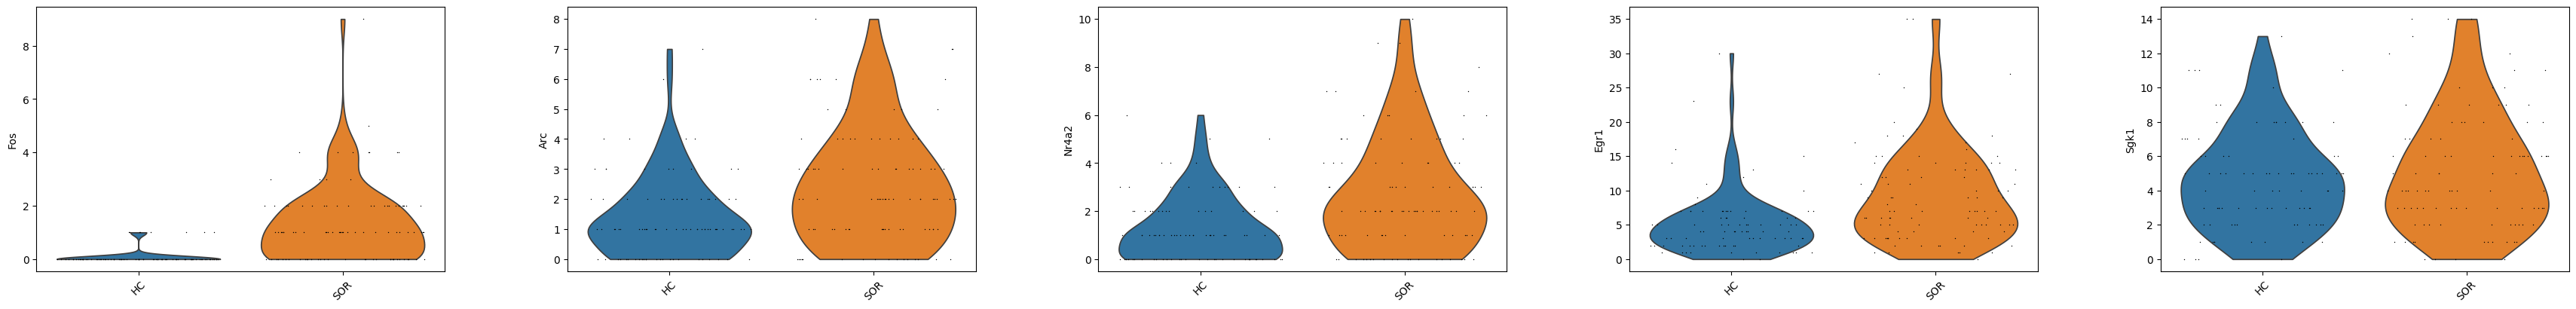

In [3]:
import scanpy as sc
import pandas as pd

# ---------- Paths to snRNA-seq data ----------
mtx_path = "/Users/bhavanasanghi/Downloads/GSE223066_split-pipe_outputs/DGE.mtx"
cell_metadata_path = "/Users/bhavanasanghi/Downloads/GSE223066_split-pipe_outputs/cell_metadata.csv"
gene_path = "/Users/bhavanasanghi/Downloads/GSE223066_split-pipe_outputs/all_genes.csv"

# ---------- Load gene expression matrix ----------
adata_sn = sc.read_mtx(mtx_path)  # transpose to get cells x genes
print("✅ Raw matrix shape (cells x genes):", adata_sn.shape)

# ---------- Load gene names ----------
genes = pd.read_csv(gene_path)
adata_sn.var_names = genes["gene_name"].astype(str).values
adata_sn.var_names_make_unique()

# ---------- Load cell metadata ----------
cell_meta = pd.read_csv(cell_metadata_path)
cell_meta.index = cell_meta["bc_wells"].astype(str)
adata_sn.obs = cell_meta
adata_sn.obs_names_make_unique()
print("✅ Metadata columns:", adata_sn.obs.columns.tolist())

# ---------- Normalization for plotting only ----------
adata_sn_plot = adata_sn.copy()
sc.pp.normalize_total(adata_sn_plot, target_sum=1e4)
sc.pp.log1p(adata_sn_plot)
print("✅ Normalization and log1p complete for plotting.")

# ---------- Filter CA2+CA3 Visium spots ----------
#adata_ca3_all = adata_combined[adata_combined.obs["Hippocampal subregions"] == "CA2+CA3"].copy()
#print(f"\n🧠 Total CA2+CA3 spots across all samples: {adata_ca3_all.n_obs}")
#print("📊 Spots per sample:\n", adata_ca3_all.obs["sample_id"].value_counts())
#print("📊 Conditions:\n", adata_ca3_all.obs["condition"].value_counts())

# ---------- Plot gene expression in Visium CA3 ----------
genes_to_plot = ["Fos", "Arc", "Nr4a2", "Egr1", "Sgk1"]
available_genes = [gene for gene in genes_to_plot if gene in adata_ca3_all.var_names]
print("✅ Genes found in Visium CA3 data:", available_genes)

if available_genes:
    sc.pl.violin(
        adata_ca3_all,
        keys=available_genes,
        groupby="condition",
        rotation=45,
        jitter=0.4,
        stripplot=True,
        show=True
    )
else:
    print("⚠️ None of the target genes found in Visium dataset.")


Spatial plot for our important genes

In [4]:
# Subset one HC and one SOR sample
adata_sor = adata_combined[adata_combined.obs["sample_id"] == "Sample1SOR"].copy()
adata_hc = adata_combined[adata_combined.obs["sample_id"] == "Sample5HC"].copy()

# Filter to CA3 spots only
adata_sor_ca3 = adata_sor[adata_sor.obs["Hippocampal subregions"].str.contains("CA3", na=False)].copy()
adata_hc_ca3 = adata_hc[adata_hc.obs["Hippocampal subregions"].str.contains("CA3", na=False)].copy()

print("✅ CA3 spots (Sample1SOR):", adata_sor_ca3.n_obs)
print("✅ CA3 spots (Sample5HC):", adata_hc_ca3.n_obs)

✅ CA3 spots (Sample1SOR): 14
✅ CA3 spots (Sample5HC): 10



🧠 Plotting Sample1SOR (CA3 spots)...


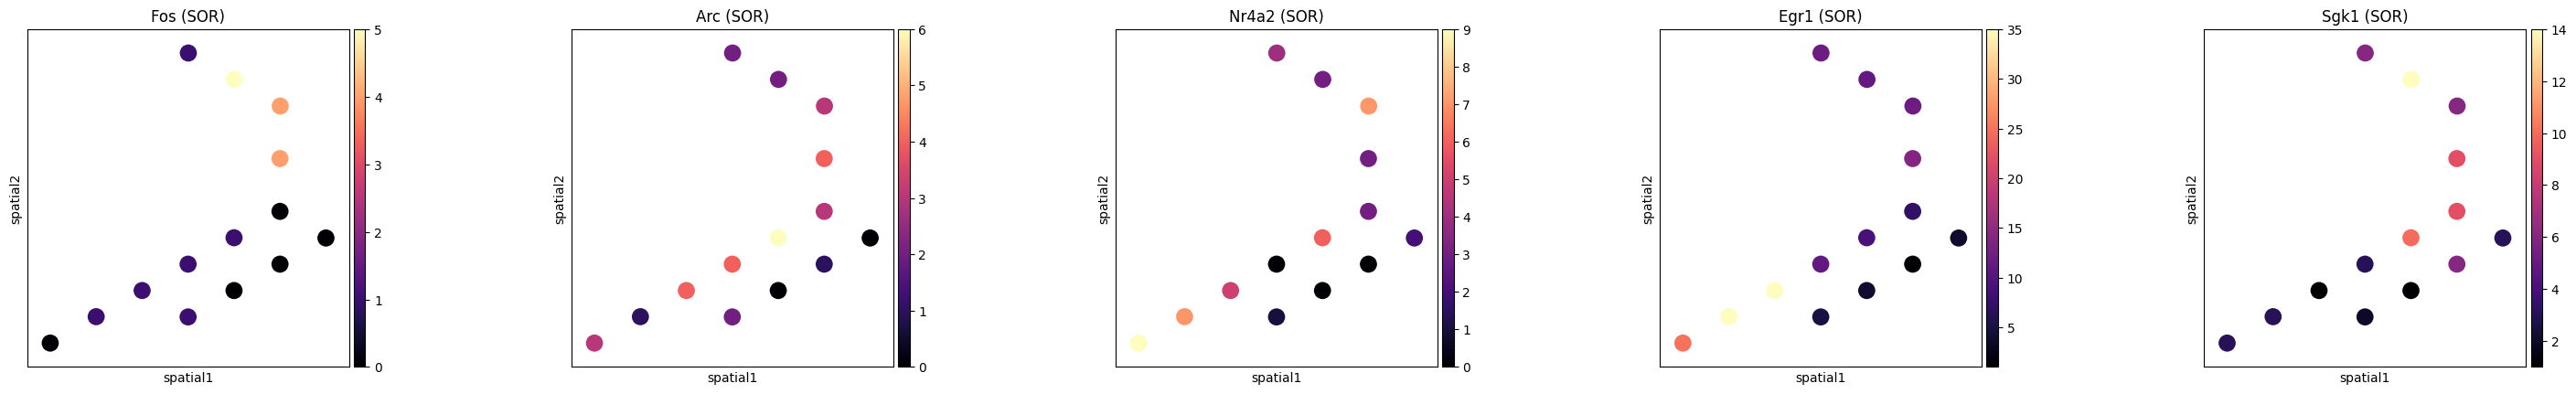


🧠 Plotting Sample5HC (CA3 spots)...


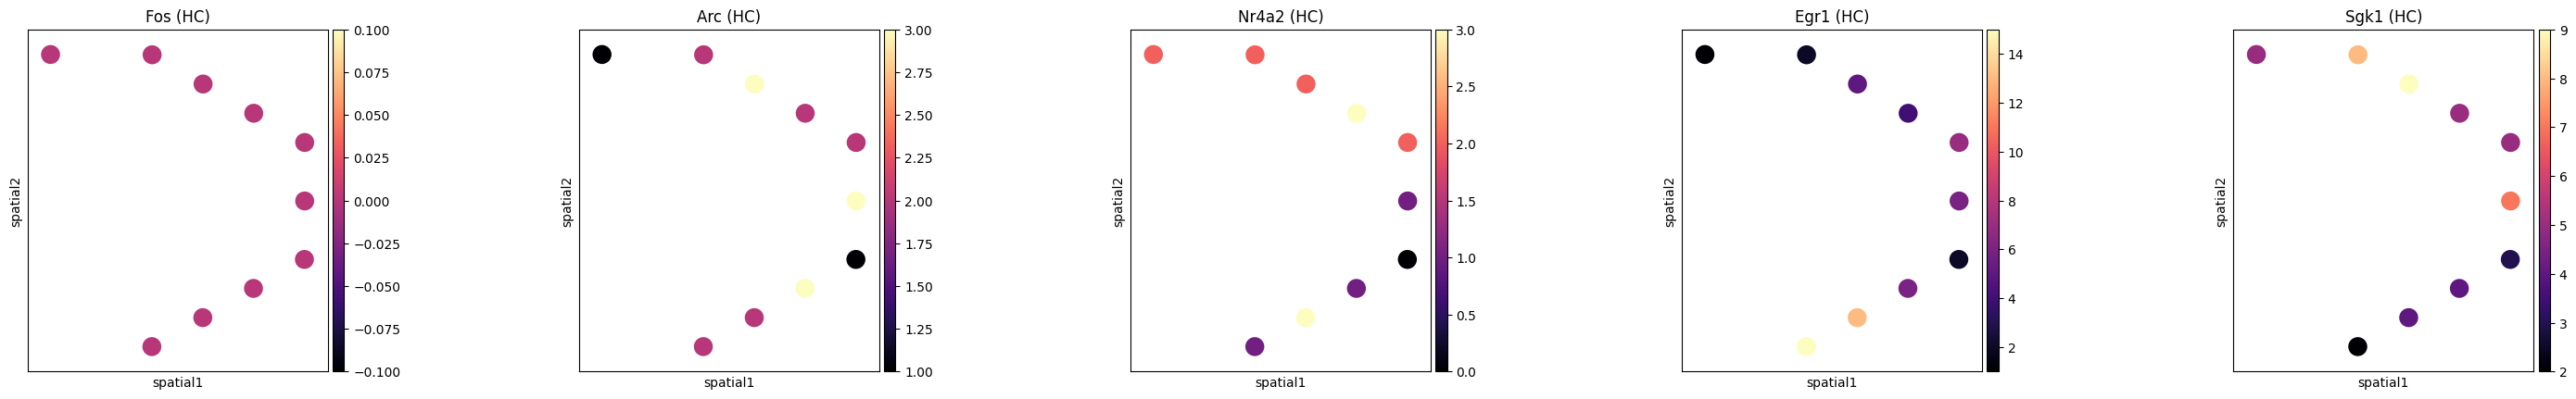

In [5]:
# Genes to plot
genes_to_plot = ["Fos", "Arc", "Nr4a2", "Egr1", "Sgk1"]
available_genes = [g for g in genes_to_plot if g in adata_sor_ca3.var_names]

# Plot in SOR
print("\n🧠 Plotting Sample1SOR (CA3 spots)...")
sc.pl.spatial(
    adata_sor_ca3,
    color=available_genes,
    spot_size=50,
    cmap="magma",
    size=1.4,
    ncols=5,
    title=[f"{gene} (SOR)" for gene in available_genes],
    show=True
)

# Plot in HC
print("\n🧠 Plotting Sample5HC (CA3 spots)...")
sc.pl.spatial(
    adata_hc_ca3,
    color=available_genes,
    spot_size=50,
    cmap="magma",
    size=1.4,
    ncols=5,
    title=[f"{gene} (HC)" for gene in available_genes],
    show=True
)


In [6]:
from scipy.stats import mannwhitneyu

for gene in ["Arc", "Nr4a2", "Egr1"]:
    hc_vals = adata_hc_ca3[:, gene].X.toarray().flatten()
    sor_vals = adata_sor_ca3[:, gene].X.toarray().flatten()
    stat, p = mannwhitneyu(sor_vals, hc_vals, alternative='greater')
    print(f"{gene}: U={stat:.2f}, p={p:.4e}")

Arc: U=81.00, p=2.6319e-01
Nr4a2: U=97.00, p=5.7897e-02
Egr1: U=98.50, p=5.0108e-02


plotting on another sample

✅ CA3 spots (Sample4SOR): 15
✅ CA3 spots (Sample5HC): 10

🧠 Plotting Sample4SOR (CA3 spots)...


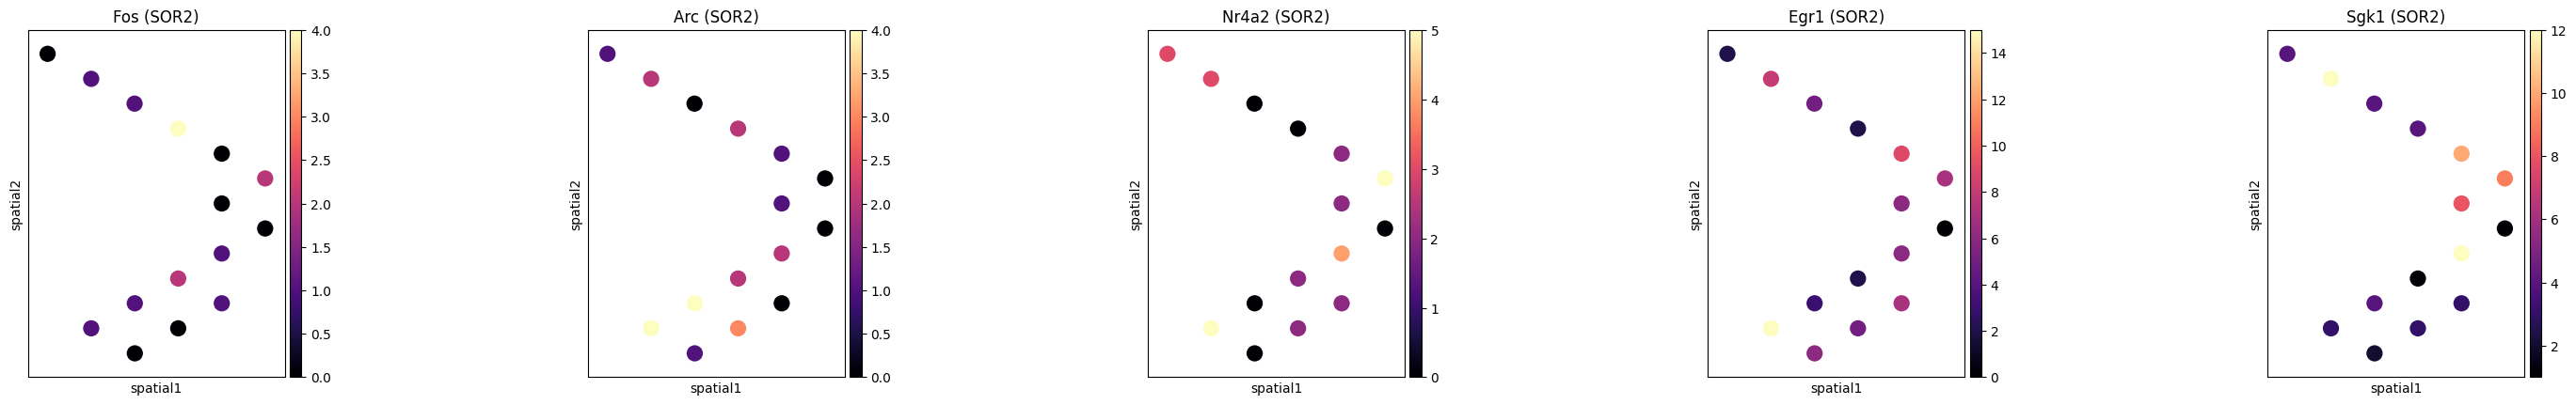


🧠 Plotting Sample5HC (CA3 spots)...


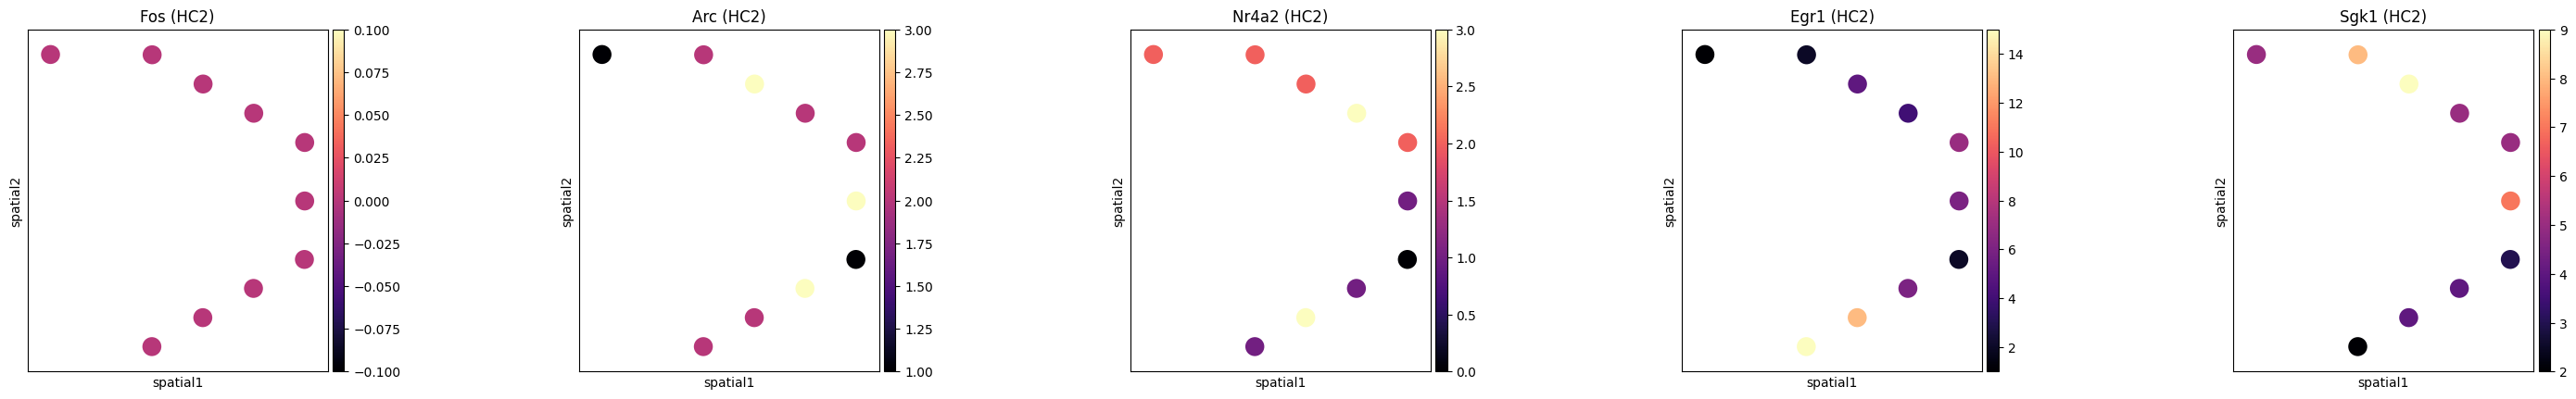

In [13]:
# Subset second HC and SOR sample
adata_sor2 = adata_combined[adata_combined.obs["sample_id"] == "Sample4SOR"].copy()
adata_hc2 = adata_combined[adata_combined.obs["sample_id"] == "Sample5HC"].copy()

# Filter CA3 spots only
adata_sor2_ca3 = adata_sor2[adata_sor2.obs["Hippocampal subregions"].str.contains("CA3", na=False)].copy()
adata_hc2_ca3 = adata_hc2[adata_hc2.obs["Hippocampal subregions"].str.contains("CA3", na=False)].copy()

print("✅ CA3 spots (Sample4SOR):", adata_sor2_ca3.n_obs)
print("✅ CA3 spots (Sample5HC):", adata_hc2_ca3.n_obs)

# Genes to plot
genes_to_plot = ["Fos", "Arc", "Nr4a2", "Egr1", "Sgk1"]
available_genes = [g for g in genes_to_plot if g in adata_sor2_ca3.var_names]

# Plot SOR Sample 14
print("\n🧠 Plotting Sample4SOR (CA3 spots)...")
sc.pl.spatial(
    adata_sor2_ca3,
    color=available_genes,
    spot_size=50,
    cmap="magma",
    size=1.4,
    ncols=5,
    title=[f"{gene} (SOR2)" for gene in available_genes],
    show=True
)

# Plot HC Sample 15
print("\n🧠 Plotting Sample5HC (CA3 spots)...")
sc.pl.spatial(
    adata_hc2_ca3,
    color=available_genes,
    spot_size=50,
    cmap="magma",
    size=1.4,
    ncols=5,
    title=[f"{gene} (HC2)" for gene in available_genes],
    show=True
)


/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/4y/hrcfh_wx73xdf5xqhx08gqrc0000gn/T/ipykernel_35780/3098568857.py:32: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sn_hvg, resolution=0.5)


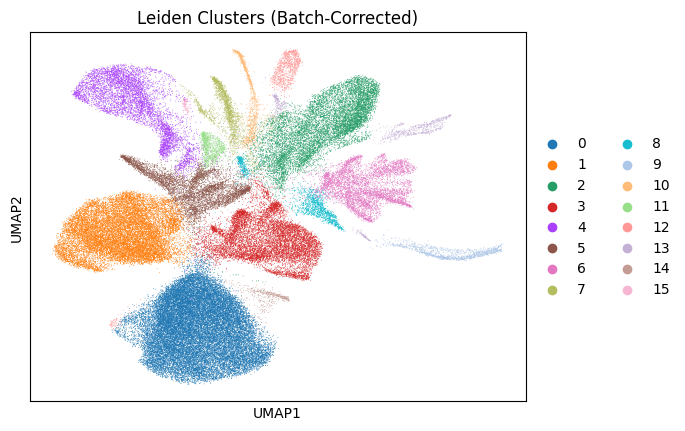

In [10]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bbknn  # Make sure you have it installed

# ---------- Step 1: QC ----------
sc.pp.calculate_qc_metrics(adata_sn, inplace=True)

# ---------- Step 2: Normalize and log transform ----------
sc.pp.normalize_total(adata_sn, target_sum=1e4)
sc.pp.log1p(adata_sn)

# ---------- Step 3: Highly Variable Genes ----------
sc.pp.highly_variable_genes(adata_sn, flavor='seurat', n_top_genes=2000)
adata_sn_hvg = adata_sn[:, adata_sn.var['highly_variable']].copy()

# ---------- Step 4: Add sample ID for batch correction ----------
# If not already present, copy sample info from raw AnnData
if "sample" not in adata_sn_hvg.obs.columns and "sample" in adata_sn.obs.columns:
    adata_sn_hvg.obs["sample"] = adata_sn.obs["sample"]

# ---------- Step 5: PCA ----------
sc.pp.scale(adata_sn_hvg, max_value=10)
sc.tl.pca(adata_sn_hvg, svd_solver='arpack')

# ---------- Step 6: Batch-corrected neighbors ----------
bbknn.bbknn(adata_sn_hvg, batch_key='sample')

# ---------- Step 7: UMAP and Leiden clustering ----------
sc.tl.umap(adata_sn_hvg)
sc.tl.leiden(adata_sn_hvg, resolution=0.5)

# ---------- Step 8: Plot updated UMAP ----------
sc.pl.umap(adata_sn_hvg, color=['leiden'], title="Leiden Clusters (Batch-Corrected)")

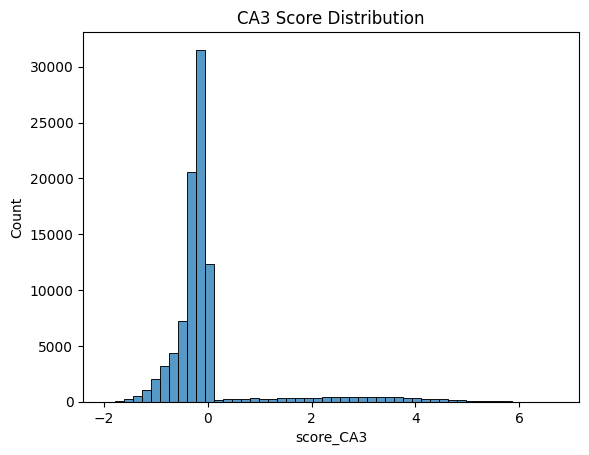

✅ Extracted 8377 CA3 pyramidal cells.


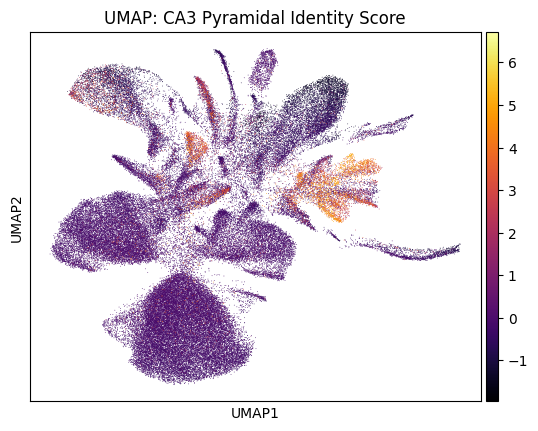

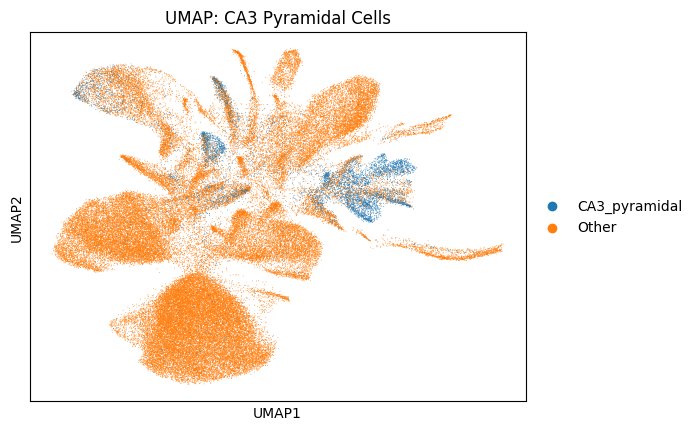

/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


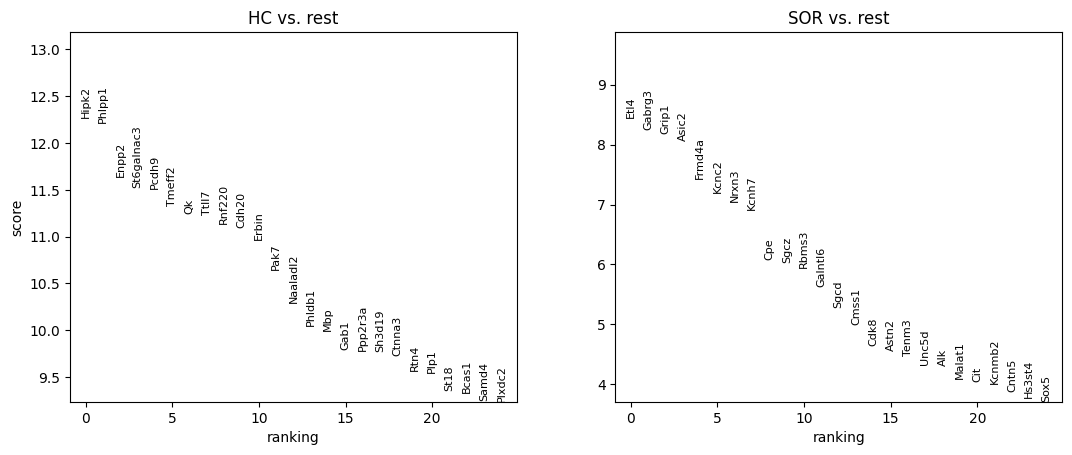

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Step 1: Score CA3 identity ----------
ca3_genes = ["Grik1", "Grm5", "Rgs14", "Neurod6", "Pcp4", "Tmem100"]
sc.tl.score_genes(adata_sn_hvg, gene_list=ca3_genes, score_name="score_CA3")

# ---------- Step 2: Visualize score distribution ----------
sns.histplot(adata_sn_hvg.obs["score_CA3"], bins=50)
plt.title("CA3 Score Distribution")
plt.xlabel("score_CA3")
plt.show()

# ---------- Step 3: Threshold and assign CA3 identity ----------
threshold = 0.8
adata_sn_hvg.obs["celltype"] = "Other"
adata_sn_hvg.obs.loc[adata_sn_hvg.obs["score_CA3"] > threshold, "celltype"] = "CA3_pyramidal"

# ---------- Step 4: Subset CA3 pyramidal cells ----------
adata_ca3_ref = adata_sn_hvg[adata_sn_hvg.obs["celltype"] == "CA3_pyramidal"].copy()
print(f"✅ Extracted {adata_ca3_ref.n_obs} CA3 pyramidal cells.")

# ---------- Step 5: Plot UMAP of score and celltype ----------
sc.pl.umap(adata_sn_hvg, color="score_CA3", cmap="inferno", title="UMAP: CA3 Pyramidal Identity Score")
sc.pl.umap(adata_sn_hvg, color="celltype", title="UMAP: CA3 Pyramidal Cells")

# ---------- Step 6: Add condition (SOR vs HC) ----------
if "sample" in adata_ca3_ref.obs.columns:
    adata_ca3_ref.obs["condition"] = adata_ca3_ref.obs["sample"].apply(
        lambda x: "SOR" if "SOR" in str(x) else "HC"
    )
else:
    print("⚠️ 'sample' column not found. Cannot assign condition labels.")

# ---------- Step 7: DEG analysis (SOR vs HC within CA3 pyramidal) ----------
if "condition" in adata_ca3_ref.obs.columns:
    sc.tl.rank_genes_groups(
        adata_ca3_ref,
        groupby="condition",
        method="wilcoxon",
        key_added="rank_genes_sor_vs_hc"
    )

    sc.pl.rank_genes_groups(
        adata_ca3_ref,
        key="rank_genes_sor_vs_hc",
        n_genes=25,
        sharey=False
    )


COSINE SIMILARITY

✅ 1589 genes shared between snRNA-seq CA3 and Visium CA3


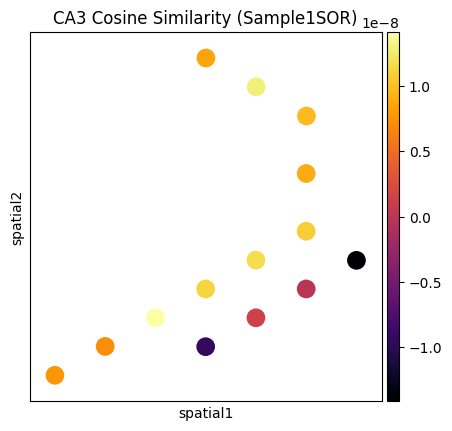

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ✅ Define snRNA-seq CA3 reference using normalized + log-transformed values
#adata_ca3_ref = adata_sn_hvg[adata_sn_hvg.obs["celltype"] == "CA3_pyramidal"].copy()

# Step 1: Intersect genes
shared_genes = adata_ca3_ref.var_names.intersection(adata_ca3_all.var_names)
print(f"✅ {len(shared_genes)} genes shared between snRNA-seq CA3 and Visium CA3")

# Step 2: Extract data matrices
# snRNA-seq: average CA3 pyramidal expression (reference vector)
X_sn = adata_ca3_ref[:, shared_genes].X.toarray() if not isinstance(adata_ca3_ref.X, np.ndarray) else adata_ca3_ref[:, shared_genes].X
ca3_profile = X_sn.mean(axis=0).reshape(1, -1)  # shape: (1, genes)

# Visium: CA3 spot expression
X_visium = adata_ca3_all[:, shared_genes].X.toarray() if not isinstance(adata_ca3_all.X, np.ndarray) else adata_ca3_all[:, shared_genes].X

from sklearn.preprocessing import StandardScaler

# Step 1: Zero-center both matrices
X_sn_centered = StandardScaler(with_std=False).fit_transform(X_sn)
X_visium_centered = StandardScaler(with_std=False).fit_transform(X_visium)

# Step 2: Recompute mean profile
ca3_profile_centered = X_sn_centered.mean(axis=0).reshape(1, -1)

# Step 3: Cosine similarity
similarities = cosine_similarity(X_visium_centered, ca3_profile_centered).flatten()
adata_ca3_all.obs["cosine_CA3"] = similarities


# Step 4: Plot for a representative sample (e.g., Sample1SOR)
adata_sor1_cosine = adata_ca3_all[adata_ca3_all.obs["sample_id"] == "Sample1SOR"].copy()
sc.pl.spatial(
    adata_sor1_cosine,
    color="cosine_CA3",
    cmap="inferno",
    size=1.4,
    spot_size=50,
    title="CA3 Cosine Similarity (Sample1SOR)",
    show=True
)


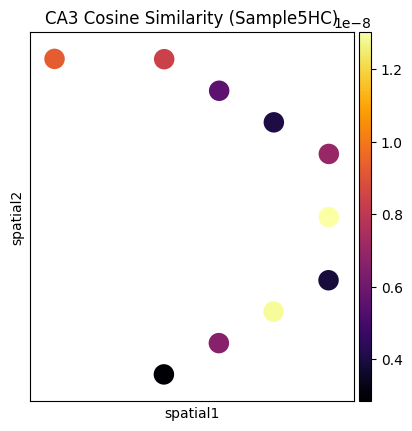

In [21]:
# Subset CA3 spots from Sample5HC
adata_hc1_cosine = adata_ca3_all[adata_ca3_all.obs["sample_id"] == "Sample5HC"].copy()

# Plot cosine similarity for Sample5HC
sc.pl.spatial(
    adata_hc1_cosine,
    color="cosine_CA3",
    cmap="inferno",
    size=1.4,
    spot_size=50,
    title="CA3 Cosine Similarity (Sample5HC)",
    show=True
)


In [25]:
from scipy.stats import mannwhitneyu

sor_vals = adata_ca3_all[adata_ca3_all.obs["condition"] == "SOR"].obs["cosine_CA3"]
hc_vals = adata_ca3_all[adata_ca3_all.obs["condition"] == "HC"].obs["cosine_CA3"]

stat, p = mannwhitneyu(sor_vals, hc_vals, alternative="greater")
print(f"Mann–Whitney U: {stat:.2f}, p = {p:.4e}")

Mann–Whitney U: 3750.00, p = 9.6983e-01


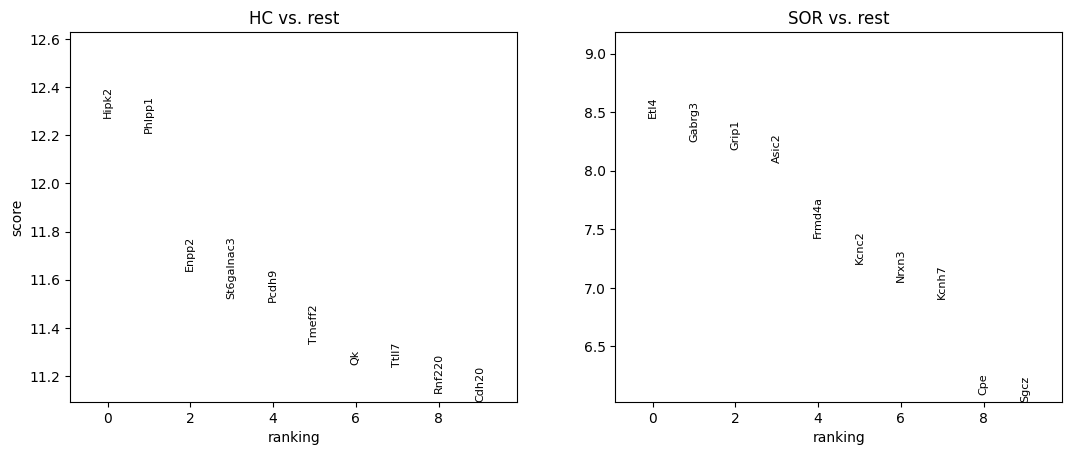

In [26]:
sc.pl.rank_genes_groups(adata_ca3_ref, key='rank_genes_sor_vs_hc', n_genes=10, sharey=False)

In [27]:
import pandas as pd

de_table = sc.get.rank_genes_groups_df(adata_ca3_ref, group='SOR', key='rank_genes_sor_vs_hc')
top_sor = de_table.head(10)[['names', 'scores', 'logfoldchanges', 'pvals_adj']]
print(top_sor)


    names    scores  logfoldchanges     pvals_adj
0    Etl4  8.455014        0.791411  1.240232e-15
1  Gabrg3  8.242917        0.683345  6.463910e-15
2   Grip1  8.174459        0.538312  1.100736e-14
3   Asic2  8.063565        0.814957  2.600043e-14
4  Frmd4a  7.430148             NaN  2.711916e-12
5   Kcnc2  7.203160        0.881278  1.339911e-11
6   Nrxn3  7.049493        0.764703  3.990459e-11
7   Kcnh7  6.905905        1.527333  1.072782e-10
8     Cpe  6.082866       -1.858143  2.018005e-08
9    Sgcz  6.027646        0.450906  2.796055e-08


In [28]:
adata_ca3_all.obs['dv_axis'] = pd.qcut(
    adata_ca3_all.obs['array_row'], q=3, labels=['dorsal', 'intermediate', 'ventral']
)

/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/bhavanasanghi/Library/Python/3.9/lib/python/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


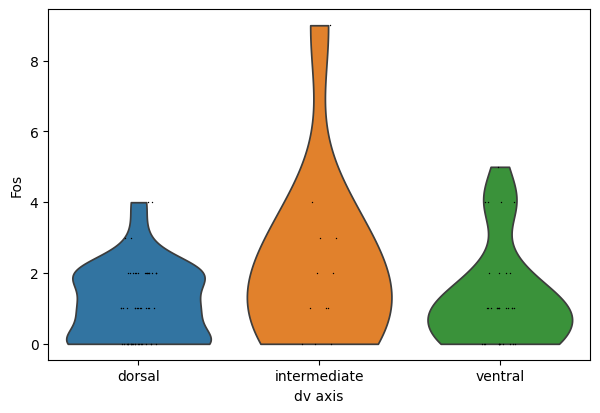

In [29]:
sc.pl.violin(
    adata_ca3_all[adata_ca3_all.obs["condition"] == "SOR"],
    keys="Fos", groupby="dv_axis"
)


In [30]:
ca3_genes = ["Grik1", "Grm5", "Rgs14", "Neurod6", "Pcp4", "Tmem100"]
sc.tl.score_genes(adata_ca3_all, gene_list=ca3_genes, score_name="CA3_score")


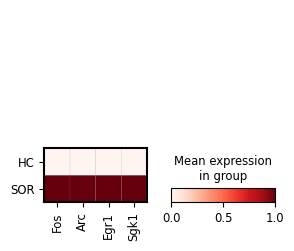

In [33]:
sc.pl.matrixplot(
    adata_ca3_all,
    var_names=["Fos", "Arc", "Egr1", "Sgk1"],
    groupby="condition",
    cmap="Reds",
    standard_scale="var"
)


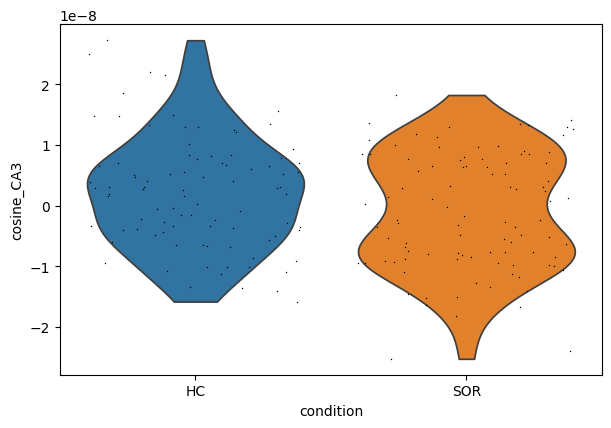

In [15]:
sc.pl.violin(adata_ca3_all, keys="cosine_CA3", groupby="condition", jitter=0.4, stripplot=True)

optional but strong analysis

Available IEGs for scoring: ['Fos', 'Arc', 'Egr1']


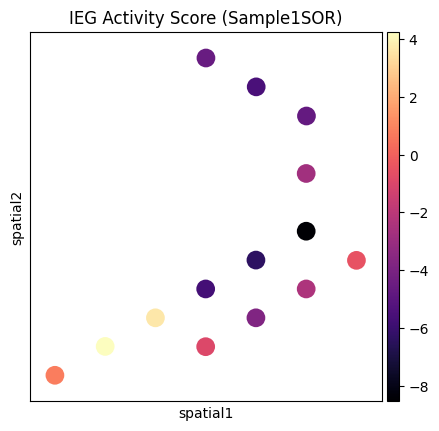

In [37]:
# Define immediate early gene set (you can include Sgk1 optionally)
ieg_genes = ["Fos", "Arc", "Egr1"]

# Check availability
available_ieg = [g for g in ieg_genes if g in adata_ca3_all.var_names]
print("Available IEGs for scoring:", available_ieg)

# Score the genes in Visium CA3 data
sc.tl.score_genes(adata_ca3_all, gene_list=available_ieg, score_name="IEG_score")

# Plot spatial IEG score for a representative SOR sample
adata_sor1 = adata_ca3_all[adata_ca3_all.obs["sample_id"] == "Sample1SOR"].copy()

sc.pl.spatial(
    adata_sor1,
    color="IEG_score",
    cmap="magma",
    size=1.4,
    spot_size=50,
    title="IEG Activity Score (Sample1SOR)",
    show=True
)


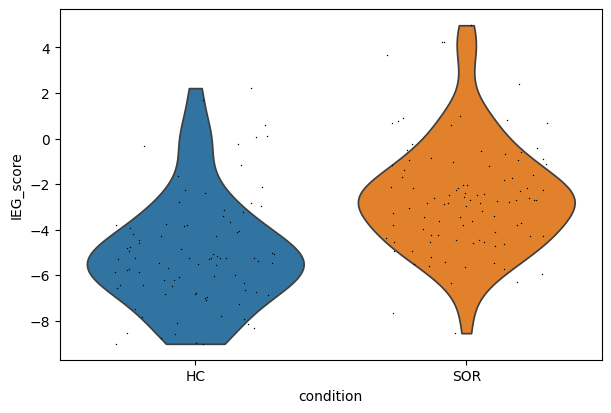

In [36]:
sc.pl.violin(
    adata_ca3_all,
    keys="IEG_score",
    groupby="condition",
    jitter=0.3,
    stripplot=True,
    #title="IEG Score in SOR vs HC CA3 Spots"
)

In [47]:
ca3_identity_genes = ["Grik1", "Grm5", "Pcp4", "Rgs14", "Tmem100", "Neurod6"]

present = [g for g in ca3_identity_genes if g in adata_ca3_ref.var_names]
print("Found genes:", present)


Found genes: ['Grik1']


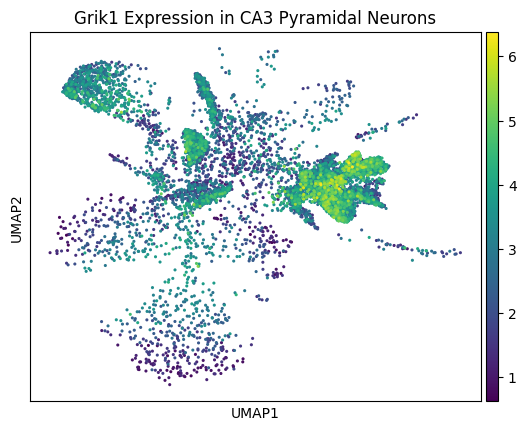

In [48]:
sc.pl.umap(
    adata_ca3_ref,
    color=present,
    cmap="viridis",
    size=20,
    ncols=2,
    title=[f"{g} Expression in CA3 Pyramidal Neurons" for g in present],
    show=True
)


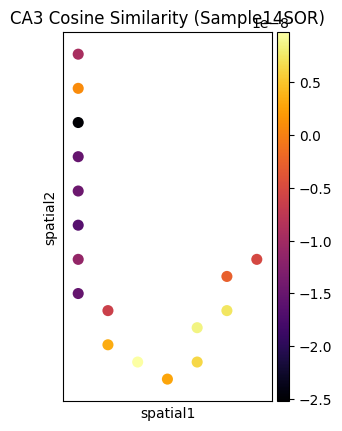

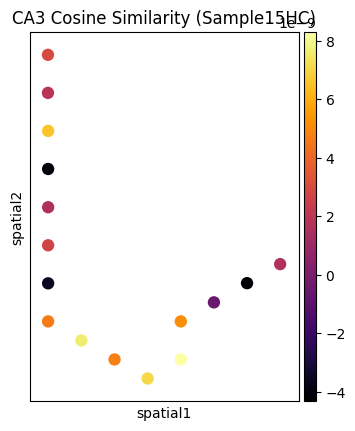

In [50]:
# Sample 14 SOR
adata_sor14 = adata_ca3_all[adata_ca3_all.obs["sample_id"] == "Sample14SOR"].copy()

sc.pl.spatial(
    adata_sor14,
    color="cosine_CA3",
    cmap="inferno",
    size=1.4,
    spot_size=50,
    title="CA3 Cosine Similarity (Sample14SOR)",
    show=True
)

# Sample 15 HC
adata_hc15 = adata_ca3_all[adata_ca3_all.obs["sample_id"] == "Sample15HC"].copy()

sc.pl.spatial(
    adata_hc15,
    color="cosine_CA3",
    cmap="inferno",
    size=1.4,
    spot_size=50,
    title="CA3 Cosine Similarity (Sample15HC)",
    show=True
)


Genes available for dot plot: ['Fos', 'Arc', 'Egr1', 'Sgk1']


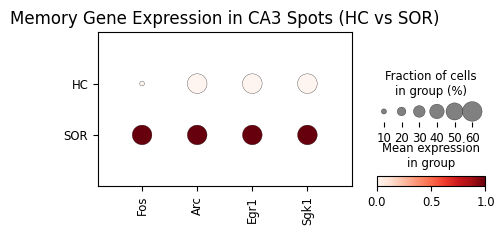

In [51]:
# Define the genes of interest
memory_genes = ["Fos", "Arc", "Egr1", "Sgk1"]

# Filter to genes that exist in your Visium CA3 dataset
present_genes = [g for g in memory_genes if g in adata_ca3_all.var_names]
print("Genes available for dot plot:", present_genes)

# Create dot plot grouped by condition (SOR vs HC)
sc.pl.dotplot(
    adata_ca3_all,
    var_names=present_genes,
    groupby="condition",
    standard_scale="var",
    color_map="Reds",
    dot_max=0.6,
    figsize=(5, 2),
    show=True,
    title="Memory Gene Expression in CA3 Spots (HC vs SOR)"
)

In [52]:
# Optional for snRNA-seq CA3 reference if genes are available
genes_sn = [g for g in memory_genes if g in adata_ca3_ref.var_names]
if genes_sn:
    sc.pl.dotplot(
        adata_ca3_ref,
        var_names=genes_sn,
        groupby="condition",
        standard_scale="var",
        color_map="Blues",
        dot_max=0.6,
        figsize=(5, 2),
        title="Memory Gene Expression in snRNA-seq CA3 Neurons (HC vs SOR)"
    )

In [53]:
from scipy.stats import mannwhitneyu

sor_ieg = adata_ca3_all[adata_ca3_all.obs["condition"] == "SOR"].obs["IEG_score"]
hc_ieg = adata_ca3_all[adata_ca3_all.obs["condition"] == "HC"].obs["IEG_score"]

stat_ieg, pval_ieg = mannwhitneyu(sor_ieg, hc_ieg, alternative="greater")

print(f"Mann–Whitney U test on IEG score: U={stat_ieg:.2f}, p={pval_ieg:.4e}")

Mann–Whitney U test on IEG score: U=7033.50, p=3.3546e-12


In [54]:
sor_cosine = adata_ca3_all[adata_ca3_all.obs["condition"] == "SOR"].obs["cosine_CA3"]
hc_cosine = adata_ca3_all[adata_ca3_all.obs["condition"] == "HC"].obs["cosine_CA3"]

stat_cos, pval_cos = mannwhitneyu(sor_cosine, hc_cosine, alternative="greater")

print(f"Mann–Whitney U test on cosine similarity: U={stat_cos:.2f}, p={pval_cos:.4e}")

Mann–Whitney U test on cosine similarity: U=3750.00, p=9.6983e-01


In [55]:
from scipy.stats import spearmanr

# Drop NA values (if any)
valid = adata_ca3_all.obs[["cosine_CA3", "IEG_score"]].dropna()

# Spearman correlation
corr_val, corr_pval = spearmanr(valid["cosine_CA3"], valid["IEG_score"])
print(f"Spearman correlation: ρ = {corr_val:.3f}, p = {corr_pval:.4e}")

Spearman correlation: ρ = -0.385, p = 4.6027e-08


In [56]:
import pandas as pd
from scipy.stats import chi2_contingency

# Step 1: Rank spots by cosine similarity
adata_ca3_all.obs["cosine_rank"] = adata_ca3_all.obs["cosine_CA3"].rank(ascending=False)

# Step 2: Select top N spots
top_n = 100
adata_ca3_all.obs["top_cosine"] = adata_ca3_all.obs["cosine_rank"] <= top_n

# Step 3: Build contingency table
contingency = pd.crosstab(adata_ca3_all.obs["top_cosine"], adata_ca3_all.obs["condition"])
print("Contingency table:\n", contingency)

# Step 4: Run Chi-square test
chi2, pval, _, _ = chi2_contingency(contingency)
print(f"Chi-square test: χ² = {chi2:.2f}, p = {pval:.4e}")


Contingency table:
 condition   HC  SOR
top_cosine         
False       38   51
True        52   48
Chi-square test: χ² = 1.28, p = 2.5747e-01
